<a href="https://colab.research.google.com/github/usama9133/usama9133/blob/main/Week3_CNN_Lab_YourID.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

OpenCV: 4.14.0
Python: 3.13.15
PyTorch: 2.11.0+cpu | torchvision: 0.26.0+cpu
Training on: cpu
train / val / test sizes: 45000 5000 10000


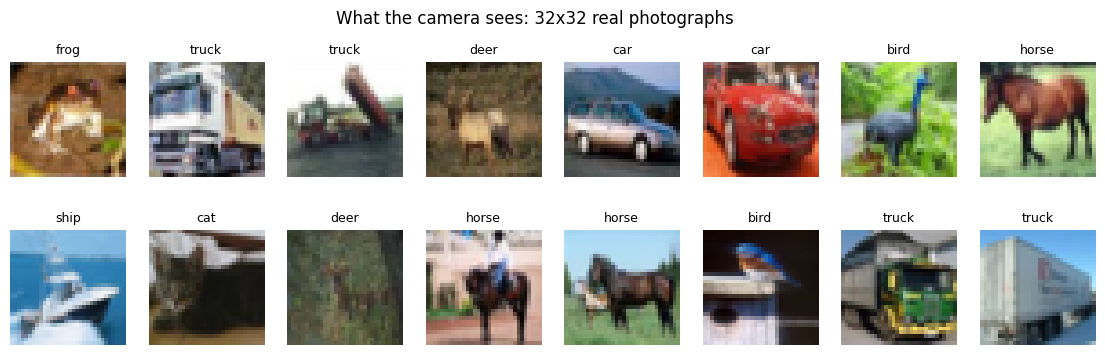

Images per class: {'plane': np.int64(5000), 'car': np.int64(5000), 'bird': np.int64(5000), 'cat': np.int64(5000), 'deer': np.int64(5000), 'dog': np.int64(5000), 'frog': np.int64(5000), 'horse': np.int64(5000), 'ship': np.int64(5000), 'truck': np.int64(5000)}
images: torch.Size([128, 3, 32, 32]) | labels: torch.Size([128])
pixel range after normalisation: -1.99 to 2.13
SceneCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_di

In [16]:
# Check library versions

import sys
import random
import numpy as np
import torch
import torchvision

# Optional OpenCV import
try:
    import cv2
    print("OpenCV:", cv2.__version__)
except ImportError:
    cv2 = None
    print("OpenCV not found (only needed for the optional photo test)")

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Select device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Print environment information
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__, "| torchvision:", torchvision.__version__)
print("Training on:", device)



import torch
import torchvision
import torchvision.transforms as T

from torch.utils.data import DataLoader, random_split

# CIFAR-10 classes
CLASSES = [
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# CIFAR-10 statistics
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

# Transform
tf = T.Compose([
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])

# Download datasets
train_full = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=tf
)

test_set = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=tf
)

# Split training and validation sets
train_set, val_set = random_split(
    train_full,
    [45000, 5000],
    generator=torch.Generator().manual_seed(42)
)

# Batch size
BATCH = 128

# Data loaders
train_loader = DataLoader(
    train_set,
    batch_size=BATCH,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH,
    shuffle=False,
    num_workers=2
)

print(
    "train / val / test sizes:",
    len(train_set),
    len(val_set),
    len(test_set)
)







import matplotlib.pyplot as plt
import numpy as np
import torchvision

# Load raw CIFAR-10 images (without transforms)
raw = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=False
)

# Display 16 sample images
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

for ax, i in zip(axes.flat, range(16)):
    img, label = raw[i]
    ax.imshow(img)
    ax.set_title(CLASSES[label], fontsize=9)
    ax.axis("off")

plt.suptitle("What the camera sees: 32x32 real photographs")
plt.show()

# Count images per class
print(
    "Images per class:",
    dict(zip(CLASSES, np.bincount(raw.targets)))
)




images, labels = next(iter(train_loader))
print("images:", images.shape, "| labels:", labels.shape)
print("pixel range after normalisation: %.2f to %.2f" % (images.min(), images.max()))






import torch.nn as nn

class SceneCNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SceneCNN().to(device)
print(model)